<a href="https://colab.research.google.com/github/chantal-e/Startup-Funding-and-Outcome-Analysis/blob/main/startup_funding_and_outcome_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up notebook

We import pandas, and set up the csv file so it is easy to use throughout the analysis.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/chantal-e/Startup-Funding-and-Outcome-Analysis/main/data/startup_success_dataset.csv"
df = pd.read_csv(url)
df.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


# Exploratory Data Analysis (EDA)

First, we check the structure of our dataset and look for missing values. This helps us understand the data types, number of entries, and whether we need to clean the data.

In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


,0
funding_rounds,0
founder_experience_years,0
team_size,0
market_size_billion,0
product_traction_users,0
burn_rate_million,0
revenue_million,0
investor_type,0
sector,0
founder_background,0


**Observation:**  
- The dataset has 100,000 rows and 11 columns.  
- All columns have complete data (no missing values).  
- Numeric columns: funding, experience, team size, market size, users, burn rate, and revenue.  
- Categorical columns: investor type, sector, founder background, and outcome.  

This means we can start analysis directly without cleaning missing values.

## Outcome Overview

We are going to view how many startups fall into IPO, Aquisition or Failure using a bar chart.

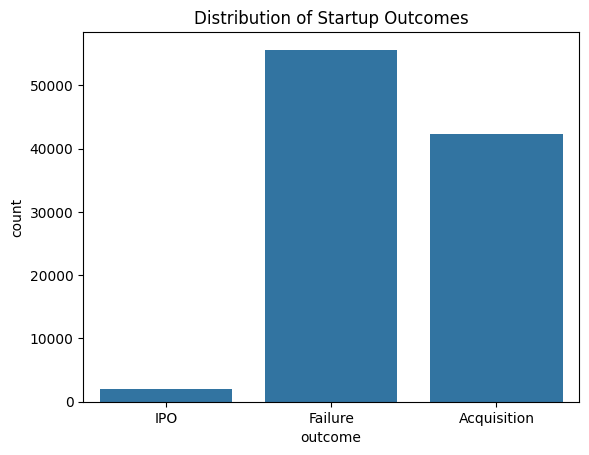

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='outcome', data=df)
plt.title("Distribution of Startup Outcomes")
plt.show()

## Overall Startup Outcomes

We calculate the percentage of startups in each outcome category (IPO, Acquisition, Failure) to understand the general success/failure distribution in the dataset.

In [8]:
outcome_percentage = df['outcome'].value_counts(normalize=True) * 100
outcome_percentage = outcome_percentage.round(2)
print(outcome_percentage)

outcome
Failure        55.61
Acquisition    42.34
IPO             2.05
Name: proportion, dtype: float64


**Observation:**  
- Majority of startups failed (55.61%), while 42.34% were acquired and 2.05% reached IPO.  

This gives a baseline understanding of startup success rates before diving into sector, funding, or founder analysis.